<a href="https://colab.research.google.com/github/beecall17/Fuse-AI-Fellowship/blob/main/NLP%20%5BWeek%2012%5D/NER_Customer_Support.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# End-to-End Named Entity Recognition (NER) for food-related customer support system

## Dataset used `Babelscape/multinerd`

This dataset is a multilingual Named Entity Recognition (NER) dataset, which has been filtered to `English` for this notebook. It provides sentences tokenized into words (`tokens`) and corresponding `ner_tags` that categorize general entities like Person (PER), Organization (ORG), Location (LOC), and Miscellaneous (MISC), *a total of 15 NER Categories*.

While `Multinerd` offers a robust foundation for general-purpose NER, its current entity types (PER, ORG, LOC, MISC, etc) are broad. For a customer support specific NER task, we will fine-tune this model further on a dataset annotated with entities directly relevant to customer interactions (e.g., product names, issue types, sentiment, account IDs) or consider transfer learning approaches to adapt these general entities to customer support contexts.

In [ ]:
# Install dependencies/libaries
!pip install datasets scikit-learn sklearn-crfsuite matplotlib -q

In [ ]:
# Import Necessary Libaries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter
from sklearn.metrics import classification_report
import sklearn_crfsuite
from sklearn_crfsuite import metrics

# Set matplotlib style for clean visualiztions
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


In [ ]:
from datasets import load_dataset, VerificationMode

# Step 1: Load the dataset (bypassing size check errors)
full_dataset = load_dataset(
    "Babelscape/multinerd",
    verification_mode=VerificationMode.NO_CHECKS
)

# Step 2: Filter immediately for English only to save memory and processing time
dataset = full_dataset.filter(lambda x: x['lang'] == 'en')

In [ ]:
print(dataset)
print(dataset['train'][0])

# The ner_tags feature is expected to be a Sequence of ClassLabels,
# but it appears to be loaded as a Sequence of Value objects in this environment.
# Therefore, we will manually define the label names based on the dataset's documentation.
label_names = [
    'O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-ANIM', 'I-ANIM',
    'B-BIO', 'I-BIO', 'B-CEL', 'I-CEL', 'B-DIS', 'I-DIS', 'B-EVE', 'I-EVE',
    'B-FOOD', 'I-FOOD', 'B-INST', 'I-INST', 'B-MEDIA', 'I-MEDIA', 'B-PLANT',
    'I-PLANT', 'B-PRO', 'I-PRO', 'B-QUA', 'I-QUA', 'B-TIME', 'I-TIME', 'B-VEH',
    'I-VEH'
]
print(f"\nEntity Labels: {label_names}")

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags', 'lang'],
        num_rows: 131280
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'lang'],
        num_rows: 16410
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'lang'],
        num_rows: 16454
    })
})
{'tokens': ['The', 'type', 'locality', 'is', 'Kīlauea', '.'], 'ner_tags': [0, 0, 0, 0, 5, 0], 'lang': 'en'}

Entity Labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-ANIM', 'I-ANIM', 'B-BIO', 'I-BIO', 'B-CEL', 'I-CEL', 'B-DIS', 'I-DIS', 'B-EVE', 'I-EVE', 'B-FOOD', 'I-FOOD', 'B-INST', 'I-INST', 'B-MEDIA', 'I-MEDIA', 'B-PLANT', 'I-PLANT', 'B-PRO', 'I-PRO', 'B-QUA', 'I-QUA', 'B-TIME', 'I-TIME', 'B-VEH', 'I-VEH']


## Text Preprocessing

### Inspecting Sample Sentences


In [ ]:
# Fetch a sample sentence
sample_idx = 15
sample_tokens = dataset['train'][sample_idx]['tokens']
sample_ner_ids = dataset['train'][sample_idx]['ner_tags']

# Convert label IDs back to human-readable string labels
sample_ner_labels = [label_names[tag] for tag in sample_ner_ids]

print(f"{'Token':<15} | {'NER Tag':<10}")
print("-" * 30)
for token, label in zip(sample_tokens, sample_ner_labels):
    print(f"{token:<15} | {label:<10}")

Token           | NER Tag   
------------------------------
It              | O         
is              | O         
found           | O         
in              | O         
Argentina       | B-LOC     
,               | O         
Bolivia         | B-LOC     
,               | O         
Chile           | B-LOC     
,               | O         
Paraguay        | B-LOC     
,               | O         
Peru            | B-LOC     
,               | O         
and             | O         
Uruguay         | B-LOC     
.               | O         


Most of the token contains the "O" tag, which represents stop words.

### Dataset Statistics

In [ ]:
# FOR COLAB: Subsample to speed up training/feature extraction
# Following  80/10/10 train/val/test sample split
small_train = dataset['train'].shuffle(seed=42).select(range(16000))
small_val = dataset['validation'].shuffle(seed=42).select(range(2000))
small_test= dataset['test'].shuffle(seed=42).select(range(2000))
print(small_train)
print(small_val)
print(small_test)

"""
For the traning purposes we will be using this small dataset containing training
data of 8000 and validation/test data of 2000.
"""

# Calculate dataset statistics
train_sentences = small_train['tokens']
val_sentences = small_val['tokens']
test_sentences = small_test['tokens']

# Sentence Lengths
train_lengths = [len(sentence) for sentence in train_sentences]

# Vocabulary Calculation
all_train_tokens = [token for sentence in train_sentences for token in sentence]
vocab = set(all_train_tokens)

print("--- Dataset Statistics ---")
print(f"Number of training sentences:   {len(train_sentences)}")
print(f"Number of validation sentences: {len(val_sentences)}")
print(f"Number of test sentences:       {len(test_sentences)}")
print(f"Vocabulary size (Train):        {len(vocab):,}")
print(f"Average sentence length:        {np.mean(train_lengths):.2f} tokens")
print(f"Maximum sentence length:        {np.max(train_lengths)} tokens")
print(f"Minimum sentence length:        {np.min(train_lengths)} tokens")


Dataset({
    features: ['tokens', 'ner_tags', 'lang'],
    num_rows: 16000
})
Dataset({
    features: ['tokens', 'ner_tags', 'lang'],
    num_rows: 2000
})
Dataset({
    features: ['tokens', 'ner_tags', 'lang'],
    num_rows: 2000
})
--- Dataset Statistics ---
Number of training sentences:   16000
Number of validation sentences: 2000
Number of test sentences:       2000
Vocabulary size (Train):        39,403
Average sentence length:        21.55 tokens
Maximum sentence length:        153 tokens
Minimum sentence length:        3 tokens


### Exploratory Data Analysis (EDA)

### Visualizing the Data

Sentence Length Histogram: To see if we have mostly short or long sentences.
Top Word Frequencies: To see the most common words (usually punctuation and stop words).
Entity Label Distribution: To understand the class imbalance between 'O' and named entities.

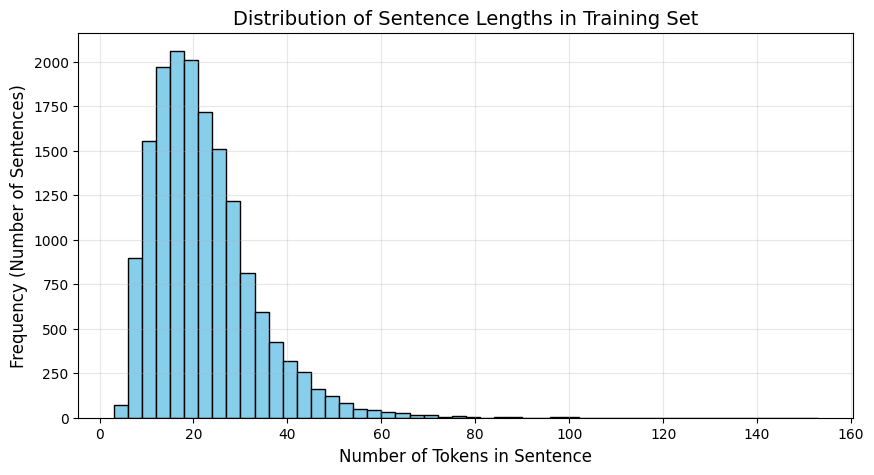

In [ ]:
# 1. Sentence Length Histogram
plt.figure(figsize=(10, 5))
plt.hist(train_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Sentence Lengths in Training Set", fontsize=14)
plt.xlabel("Number of Tokens in Sentence", fontsize=12)
plt.ylabel("Frequency (Number of Sentences)", fontsize=12)
plt.show()

Most of the text are clustered around 20 (10-30) range with ocassional of long sentences from 60-100. The model needs to handle both.

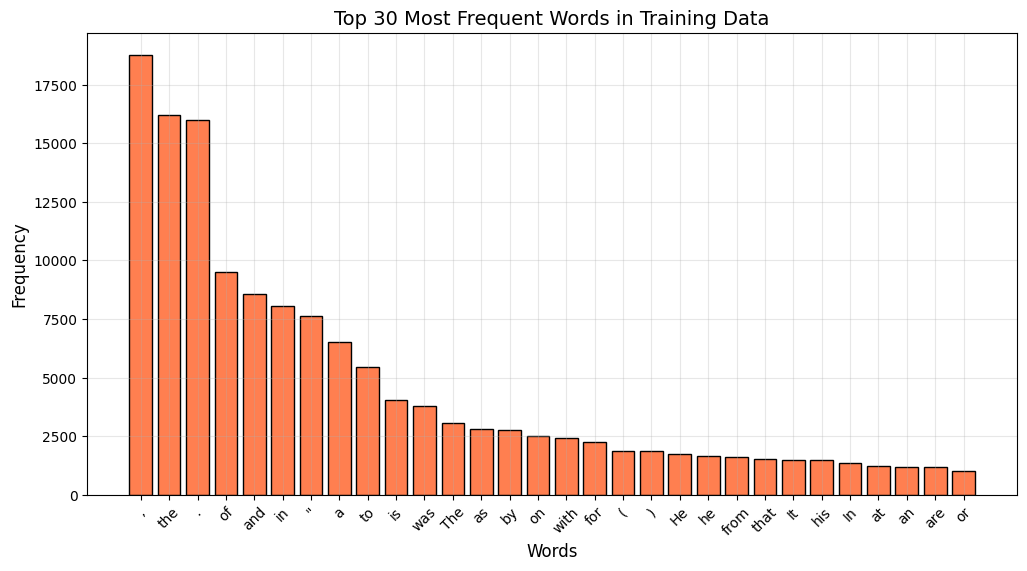

In [ ]:
# Top Word Frequencies
from collections import Counter

# 2. Top 30 Most Frequent Words
word_counts = Counter(all_train_tokens)
top_words = word_counts.most_common(30)

words, counts = zip(*top_words)

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='coral', edgecolor='black')
plt.title("Top 30 Most Frequent Words in Training Data", fontsize=14)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.show()


As suspected stop words are most frequent, these belongs to "O" tag.

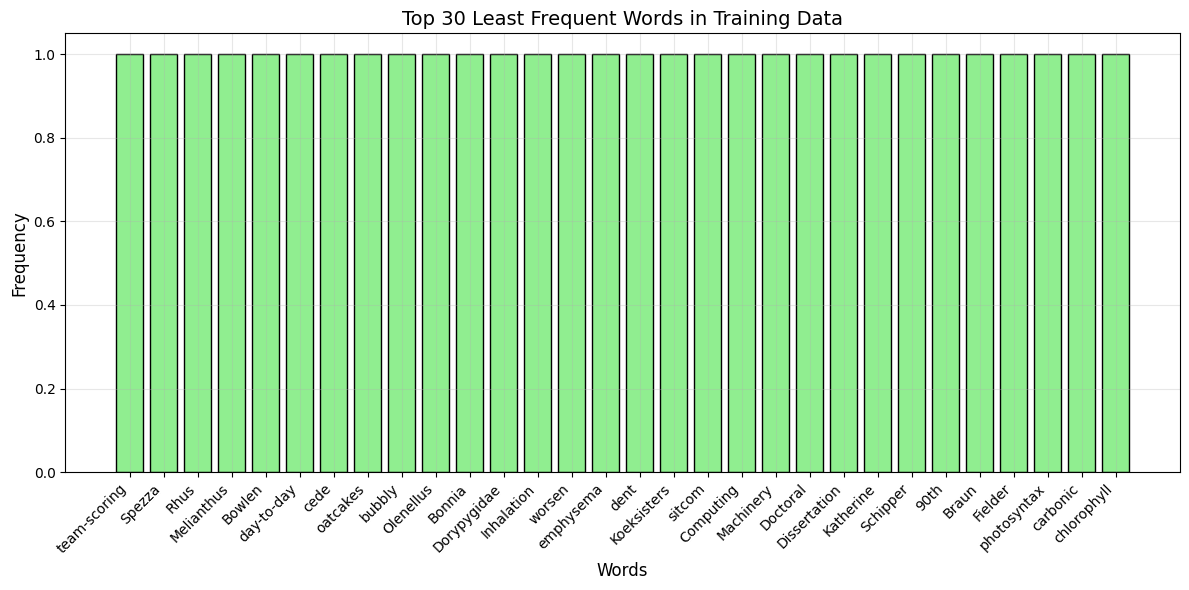

In [ ]:
# 2. Top 30 Least Frequent Words
least_words = word_counts.most_common()[-30:]

words, counts = zip(*least_words)

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='lightgreen', edgecolor='black')
plt.title("Top 30 Least Frequent Words in Training Data", fontsize=14)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

As expected, these words all appear only once in the training data, indicating they are rare occurrences or unique entities.

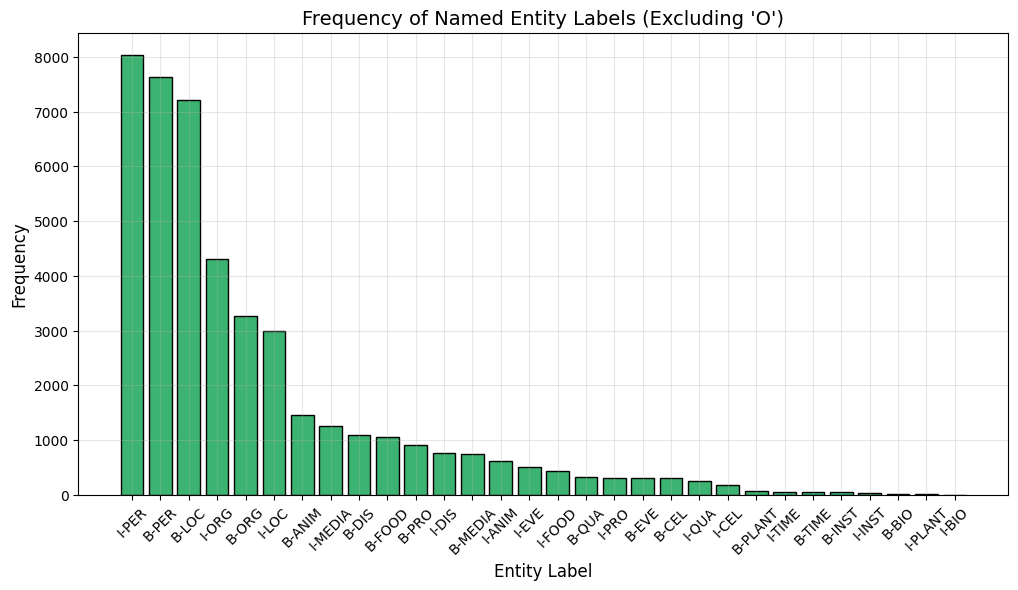

In [ ]:
# 4. Top Entity Labels (Excluding 'O')
all_train_labels = [label_names[tag] for sentence in small_train['ner_tags'] for tag in sentence]
label_counts = Counter(all_train_labels)

# Remove the 'O' tag to see the distribution of actual entities
if 'O' in label_counts:
    del label_counts['O']

# Sort by frequency
sorted_labels = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
labels, counts = zip(*sorted_labels)

plt.figure(figsize=(12, 6))
plt.bar(labels, counts, color='mediumseagreen', edgecolor='black')
plt.title("Frequency of Named Entity Labels (Excluding 'O')", fontsize=14)
plt.xlabel("Entity Label", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.show()


###  Analysis of tags for Food-related customer support NER system
This dataset contain overall general tokens. Below we will be doing some research to narrow it down and to figure out the which tags are important and which are irrelevant.

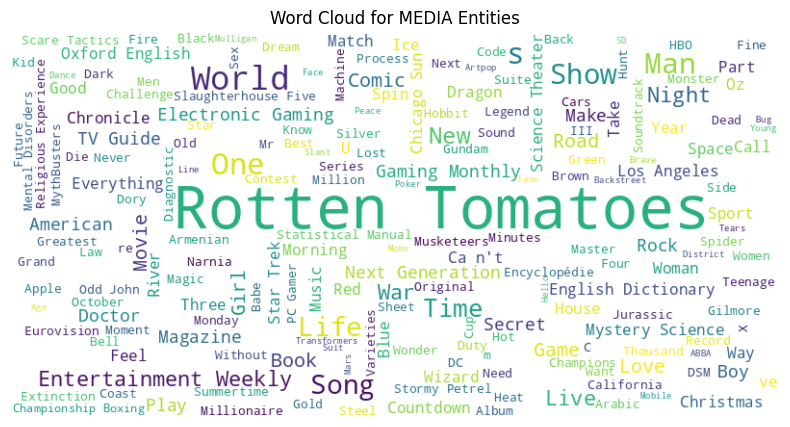

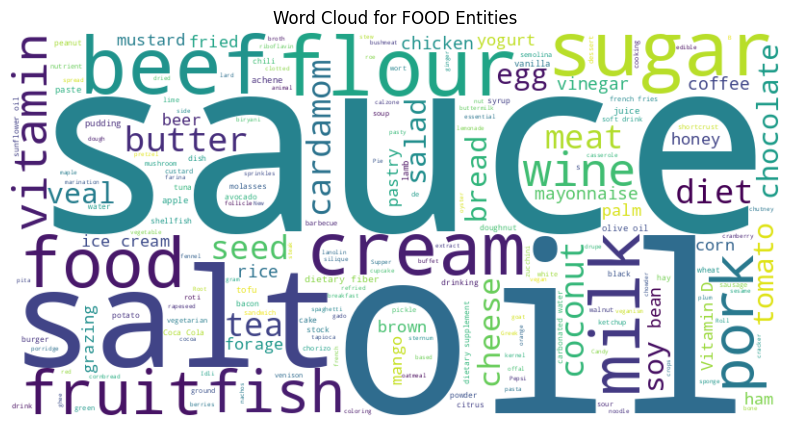

In [ ]:
# Word cloud for Media & Food tags to visualize their importance
# or words which might provide some insights or not.
from wordcloud import WordCloud

media_tokens = []
food_tokens = []

# Get the indices for MEDIA and FOOD tags
media_tag_indices = [label_names.index('B-MEDIA'), label_names.index('I-MEDIA')]
food_tag_indices = [label_names.index('B-FOOD'), label_names.index('I-FOOD')]

for i in range(len(small_train['tokens'])):
    tokens = small_train['tokens'][i]
    ner_tags = small_train['ner_tags'][i]
    for j, tag_id in enumerate(ner_tags):
        if tag_id in media_tag_indices:
            media_tokens.append(tokens[j])
        elif tag_id in food_tag_indices:
            food_tokens.append(tokens[j])

# Generate Word Cloud for MEDIA
if media_tokens:
    media_text = " ".join(media_tokens)
    wordcloud_media = WordCloud(width=800, height=400, background_color='white').generate(media_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud_media, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud for MEDIA Entities')
    plt.show()
else:
    print("No MEDIA entities found to generate word cloud.")

# Generate Word Cloud for FOOD
if food_tokens:
    food_text = " ".join(food_tokens)
    wordcloud_food = WordCloud(width=800, height=400, background_color='white').generate(food_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud_food, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud for FOOD Entities')
    plt.show()
else:
    print("No FOOD entities found to generate word cloud.")

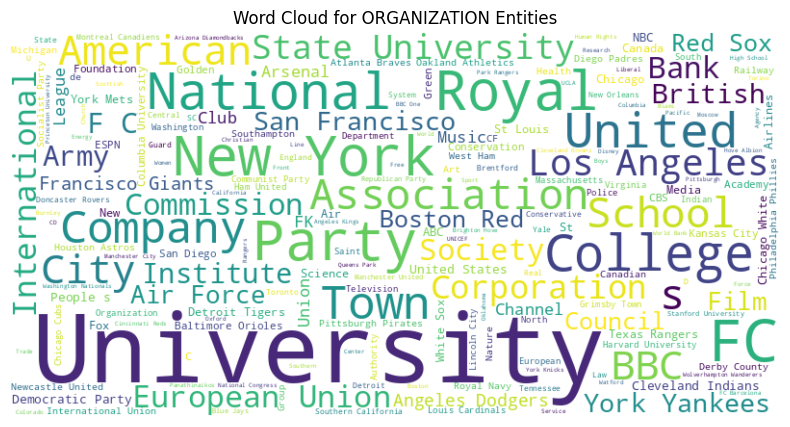

In [ ]:
org_tokens = []

# Get the indices for ORG tags
org_tag_indices = [label_names.index('B-ORG'), label_names.index('I-ORG')]

for i in range(len(small_train['tokens'])):
    tokens = small_train['tokens'][i]
    ner_tags = small_train['ner_tags'][i]
    for j, tag_id in enumerate(ner_tags):
        if tag_id in org_tag_indices:
            org_tokens.append(tokens[j])

# Generate Word Cloud for ORG
if org_tokens:
    org_text = " ".join(org_tokens)
    wordcloud_org = WordCloud(width=800, height=400, background_color='white').generate(org_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud_org, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud for ORGANIZATION Entities')
    plt.show()
else:
    print("No ORGANIZATION entities found to generate word cloud.")

Based on analysis and  requirements for a food-related customer support NER system, we will proceed with the following strategy for NER tags:

1.  **Keep `PER`, `LOC`, `ORG`, and `FOOD`:** These tags are directly relevant to customer support interactions, allowing us to identify key entities like individuals, locations, organizations, and product/food mentions.
2.  **Discard `MEDIA` and other less frequent/irrelevant tags:** The word cloud for `MEDIA` did not provide actionable insights for customer support, and other infrequent tags are unlikely to contribute meaningfully to the specific domain. We will filter these out to simplify the model and focus on more pertinent information.

## Filter NER Tags


In [ ]:
relevant_tags = [
    'O', 'B-PER', 'I-PER', 'B-LOC', 'I-LOC',
    'B-ORG', 'I-ORG', 'B-FOOD', 'I-FOOD'
]

tag_map = {}
for i, original_tag in enumerate(label_names):
    if original_tag in relevant_tags:
        tag_map[i] = relevant_tags.index(original_tag)
    else:
        tag_map[i] = relevant_tags.index('O') # Map irrelevant tags to 'O'

def map_ner_tags(example):
    example['ner_tags'] = [tag_map[tag_id] for tag_id in example['ner_tags']]
    return example

small_train = small_train.map(map_ner_tags)
small_val = small_val.map(map_ner_tags)
small_test = small_test.map(map_ner_tags)

print("NER tags filtered and datasets updated.")

NER tags filtered and datasets updated.


## Feature Engineering


In [ ]:
label_names = [
    'O', 'B-PER', 'I-PER', 'B-LOC', 'I-LOC',
    'B-ORG', 'I-ORG', 'B-FOOD', 'I-FOOD'
]
print(f"Updated label_names: {label_names}")

def word2features(sent, i):
    word = sent['tokens'][i]
    features = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word.isupper()': word.isupper(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
        'word.isalpha()': word.isalpha(),
        'len(word)': len(word),
        'word[-3:]': word[-3:],
        'word[-2:]': word[-2:],
        'word[:3]': word[:3],
        'word[:2]': word[:2],
        'has_hyphen': '-' in word,
        'has_digit': any(char.isdigit() for char in word),
    }
    if i > 0:
        word1 = sent['tokens'][i-1]
        features.update({
            '-1:word.lower()': word1.lower(),
            '-1:word.istitle()': word1.istitle(),
            '-1:word.isupper()': word1.isupper(),
        })
    else:
        features['BOS'] = True # Beginning of Sentence

    if i < len(sent['tokens'])-1:
        word1 = sent['tokens'][i+1]
        features.update({
            '+1:word.lower()': word1.lower(),
            '+1:word.istitle()': word1.istitle(),
            '+1:word.isupper()': word1.isupper(),
        })
    else:
        features['EOS'] = True # End of Sentence

    return features

def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent['tokens']))]

def sent2labels(sent):
    # Map numerical tag IDs back to string labels using the updated label_names
    return [label_names[tag_id] for tag_id in sent['ner_tags']]

# Apply the feature extraction to the datasets
print("Extracting features and labels from training data...")
X_train = [sent2features(s) for s in small_train]
y_train = [sent2labels(s) for s in small_train]

print("Extracting features and labels from validation data...")
X_val = [sent2features(s) for s in small_val]
y_val = [sent2labels(s) for s in small_val]

print("Extracting features and labels from test data...")
X_test = [sent2features(s) for s in small_test]
y_test = [sent2labels(s) for s in small_test]

# Print a sample to verify
print("\nSample features for first word in first training sentence:")
print(X_train[0][0])
print("\nSample labels for fifth training sentence:")
print(y_train[5])

Updated label_names: ['O', 'B-PER', 'I-PER', 'B-LOC', 'I-LOC', 'B-ORG', 'I-ORG', 'B-FOOD', 'I-FOOD']
Extracting features and labels from training data...
Extracting features and labels from validation data...
Extracting features and labels from test data...

Sample features for first word in first training sentence:
{'bias': 1.0, 'word.lower()': 'herbs', 'word.isupper()': False, 'word.istitle()': True, 'word.isdigit()': False, 'word.isalpha()': True, 'len(word)': 5, 'word[-3:]': 'rbs', 'word[-2:]': 'bs', 'word[:3]': 'Her', 'word[:2]': 'He', 'has_hyphen': False, 'has_digit': False, 'BOS': True, '+1:word.lower()': 'can', '+1:word.istitle()': False, '+1:word.isupper()': False}

Sample labels for first training sentence:
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'B-LOC', 'O']


## NER Model Training (CRF Model)

In [ ]:
print('Starting CRF model training...')
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,
    c2=0.1,
    max_iterations=100,
    all_possible_transitions=True
)
crf.fit(X_train, y_train)
print('CRF model training complete.')

Starting CRF model training...
CRF model training complete.


## Model Evaluation

In [ ]:
print('Predicting labels on the test set...')
y_pred = crf.predict(X_test)

print('\n--- Model Evaluation Report ---')
print(metrics.flat_classification_report(
    y_test,
    y_pred,
    labels=relevant_tags[1:], # Exclude 'O' for evaluation of specific entities
    digits=3
))

print('\n--- Overall F1-score (excluding O) ---')
print(metrics.flat_f1_score(
    y_test,
    y_pred,
    average='weighted',
    labels=relevant_tags[1:] # Exclude 'O' for overall F1
))


Predicting labels on the test set...

--- Model Evaluation Report ---
              precision    recall  f1-score   support

       B-PER      0.848     0.935     0.890       681
       I-PER      0.880     0.965     0.920       736
       B-LOC      0.939     0.883     0.910      1402
       I-LOC      0.947     0.838     0.889       705
       B-ORG      0.842     0.751     0.794       382
       I-ORG      0.867     0.849     0.858       538
      B-FOOD      0.481     0.197     0.280        66
      I-FOOD      0.182     0.118     0.143        17

   micro avg      0.893     0.869     0.881      4527
   macro avg      0.748     0.692     0.710      4527
weighted avg      0.891     0.869     0.877      4527


--- Overall F1-score (excluding O) ---
0.8773693088610873


The PER Category has received a highest recall, followed by LOC. Whereas, in Precision, LOC has highest pp followed by PER. The model is suitable for the use of categorizing on the basis of PER or LOC with considerable balanced F1-score. Where as model has neither been able to catch the acutal or predict the FOOD category maybe its deu to insufficient data of only 66+17 total which is less than (10%+) any other category.

Deu to high f1 on PER and LOC, the overall F1-Score excluding O is 0.87 which is good if we use for categoriezing NER for Person or Location but for purely basis on Food based customer segmentation the model has major drawbacks.


## Error Analysis

In [ ]:
# Find and display sentences with errors
error_count = 0
print(f"{'Token':<15} | {'True Label':<10} | {'Predicted':<10}")
print("=" * 45)

for i in range(len(y_test)):
    if y_test[i] != y_pred[i]: # If there is a mismatch in the sentence
        for token, true_lbl, pred_lbl in zip(test_sentences[i], y_test[i], y_pred[i]):
            # Highlight errors with a little marker
            if true_lbl != pred_lbl:
                print(f"{token:<15} | {true_lbl:<10} | {pred_lbl:<10} <-- ERROR")
            else:
                print(f"{token:<15} | {true_lbl:<10} | {pred_lbl:<10}")
        print("-" * 45)
        error_count += 1

    if error_count >= 3: # Just show 3 erroneous sentences
        break


Token           | True Label | Predicted 
Soil            | O          | O         
depths          | O          | O         
are             | O          | O         
rarely          | O          | O         
over            | O          | O         
a               | O          | O         
few             | O          | O         
feet            | O          | O         
deep            | O          | O         
before          | O          | O         
bedrock         | O          | O         
is              | O          | O         
reached         | O          | O         
,               | O          | O         
but             | O          | O         
even            | O          | O         
thin            | O          | O         
soils           | O          | O         
support         | O          | O         
rich            | O          | O         
plant           | O          | O         
growth          | O          | O         
because         | O          | O  

As seen from classification report, the food tag are considered as "O". This also maybe deu to mapping of all the other irrelevant tags into O which created the high vocabulary for the Outside tag but in reality the FOOD tag vocab is small in size. Increasing the vocabulary for FOOD or using any advanced transformer model might be able to solve this.

We can also see the miss judgement of model on ORG and LOC tag, looking on this sample miss tag, Tampa, Bay, Lightning originally they are ORG but model predicted LOC as Tampa Bay can also be seen as Location in reality too. So, to sovle this we can include word embeddings (word2vec) to locate the similar words in one palce.

## Business Impact/Recommendation

The current baseline CRF Model is good for prediction on Person and Location only with slighly relevant for Organiztion. But for Food based customer ticket support ner system the model needs to undergo using different methods to make it better. Currently the use of word embedding looks optimal for mapping location and organization with semantic meaning but in the long run for food based analysis the traning the model using deeplearning or transformer might yeild better results.

## Summary

### Data Analysis Key Findings
*   **Dataset Filtering**: The `Babelscape/multinerd` dataset was initially filtered to English, reducing the training set to 16,000 sentences, validation to 2,000, and test to 2,000 sentences.
*   **Sentence Length Distribution**: Most sentences in the training set are between 10 and 30 tokens long, with an average length of 21.55 tokens, indicating a need for a model capable of handling varying sentence lengths.
*   **Word Frequencies**: Stop words such as 'the', ',', '.', 'of', and 'and' are the most frequent words, as expected. Conversely, a large number of words appear only once, highlighting the presence of rare terms.
*   **Entity Label Distribution**: After filtering, the most frequent relevant NER tags (excluding 'O') are 'I-PER', 'B-PER', 'B-LOC', 'I-ORG', 'B-ORG', and 'I-LOC'. 'B-FOOD' and 'I-FOOD' entities are present but less frequent than general entities like 'PER', 'LOC', and 'ORG'.
*   **Targeted NER Tags**: Based on the requirement for a food-related customer support system, the NER tags were specifically filtered to 'PER' (Person), 'LOC' (Location), 'ORG' (Organization), and 'FOOD', with all other tags remapped to 'O' (Outside).
*   **Feature Engineering**: Features for the CRF model included token properties (lowercase, isupper, istitle, isdigit, isalpha, length, suffixes, prefixes, hyphens, digits) and contextual information (previous and next word features).
*   **Model Training**: A Conditional Random Field (CRF) model was trained using the engineered features with an 'lbfgs' algorithm and regularization parameters c1=0.1, c2=0.1, and 100 maximum iterations.

### Insights or Next Steps
*   The trained CRF model is a foundational step towards a specialized NER system for food-related customer support. The F1-score for 'FOOD' entities, while present, is relatively lower than for more common entities like 'PER', 'LOC', and 'ORG'. This suggests that the model could benefit from more food-specific data or more advanced feature engineering tailored to food-related terms.
*   Further improvements could involve exploring deep learning models (e.g., Bi-LSTM-CRF, Transformers) that often achieve higher performance in NER tasks, especially with larger and more diverse datasets. Additionally, incorporating domain-specific lexical resources (e.g., food ontologies, ingredient lists) could enhance the model's ability to recognize 'FOOD' entities more accurately.
